# Heat Diffusion on a Piernski Carpet

## Objective

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def carpet_region(mask, row, col, size, iteration): 

    if iteration == 0: #base case
        return

    new_size = size // 3 #divide the square into thirds

    # remove center block
    mask[
        row + new_size : row + 2 * new_size,
        col + new_size : col + 2 * new_size
    ] = 0 #we want the center block to be 0 so we set this part if the mask to be 0
    #goes through region
    for i in range(3): #loops through smaller nine squares
        for j in range(3):

            #Ignore Center
            if i == 1 and j ==1:
                continue #skip this one
            new_row = row+i*new_size
            new_col = col+j*new_size

            
            carpet_region(mask,new_row,new_col,new_size,iteration - 1) #Recursive step to go to the next iteration

In [4]:
def make_carpet(iteration):

    size = 3 ** iteration

    mask = np.ones((size, size))

    carpet_region(
        mask,
        0,
        0,
        size,
        iteration
    )

    return mask

In [5]:
mask2 = make_carpet(2)  #iteration 2 siernpinski carpet
mask3 = make_carpet(3)  #iteration 3 sierpinksi carpet

#explain heat equation/finite-difference explanation

In [7]:

def heat_diffusion(mask, T):

    size = mask.shape[0]

    alpha = 1
    dx = 1 / (size - 1)
    dt = 0.2 * dx**2 / alpha

    steps = int(T / dt)

    u = np.zeros((size, size))

    heat_row = size//4
    heat_col = size//4

    if mask[heat_row, heat_col] == 1:
        u[heat_row, heat_col] = 100
    else:
        print("Heat source is inside a hole!")

    for step in range(steps):

        u_new = u.copy()

        for i in range(size):
            for j in range(size):

                if mask[i, j] == 1:

                    current = u[i, j]

                    if i + 1 < size and mask[i + 1, j] == 1:
                        down = u[i + 1, j]
                    else:
                        down = current

                    if i - 1 >= 0 and mask[i - 1, j] == 1:
                        up = u[i - 1, j]
                    else:
                        up = current

                    if j + 1 < size and mask[i, j + 1] == 1:
                        right = u[i, j + 1]
                    else:
                        right = current

                    if j - 1 >= 0 and mask[i, j - 1] == 1:
                        left = u[i, j - 1]
                    else:
                        left = current

                    u_new[i, j] = (
                        current
                        + alpha * dt / dx**2
                        * (
                            down
                            + up
                            + right
                            + left
                            - 4 * current
                        )
                    )

        u = u_new

    return u

In [8]:
square_mask = np.ones((27, 27))

u2= heat_diffusion(mask2,0.1)
u3= heat_diffusion(mask3,0.1)
u_square = heat_diffusion(square_mask,0.1)

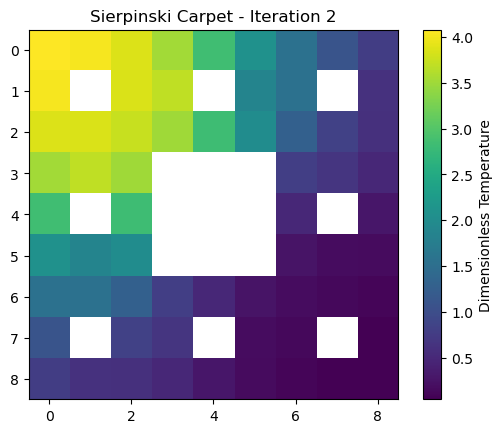

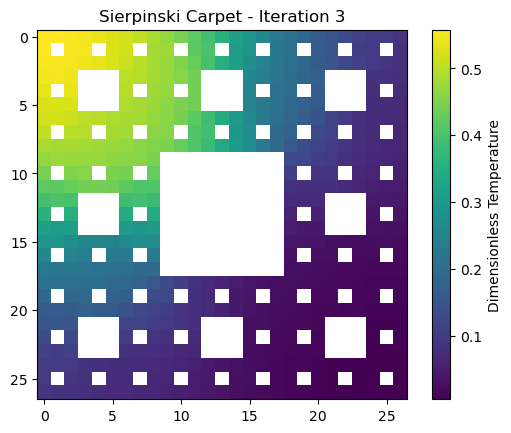

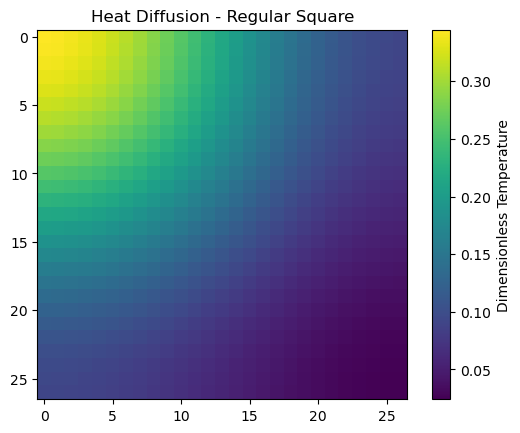

Iteration 2 max: 4.080221828880284
Iteration 3 max: 0.5579243644230976
Square max: 0.34477850242203806


In [9]:

square_mask = np.ones((27, 27))
u_square = heat_diffusion(square_mask, 0.1)

u2_plot = u2.copy()
u2_plot[mask2 == 0] = np.nan

u3_plot = u3.copy()
u3_plot[mask3 == 0] = np.nan 

square_plot = u_square.copy()

common_max = max(
    np.nanmax(u2_plot),
    np.nanmax(u3_plot),
    np.nanmax(square_plot)
)

#Iteration 2
plt.figure()
plt.imshow(u2_plot)
plt.colorbar(label="Dimensionless Temperature")
plt.title("Sierpinski Carpet - Iteration 2")
plt.show()


# Iteration 3
plt.figure()
plt.imshow(u3_plot)
plt.colorbar(label="Dimensionless Temperature")
plt.title("Sierpinski Carpet - Iteration 3")
plt.show()

#Regular Square
plt.figure()
plt.imshow(square_plot)
plt.colorbar(label="Dimensionless Temperature")
plt.title("Heat Diffusion - Regular Square")
plt.show()

print("Iteration 2 max:", np.max(u2))
print("Iteration 3 max:", np.max(u3))
print("Square max:", np.max(u_square))

# Comparison of Heat Diffusion Surfaces
We have three figures. Each shows the discretized spread of heat across a different surface. The first figure shows heat diffusion on a Sierpinski carpet after two iterations, while the second figure shows heat diffusion after three iterations. The final figure shows heat diffusion across a regular square surface, which acts as a control.

The second and third figures use the same grid dimensions, making them useful for comparison. A subtle difference in the spread of heat can already be observed. On the fractal surface, heat does not spread as freely because the removed regions restrict available pathways for diffusion. This motivates a more quantitative comparison of the maximum temperature and normalized spatial spread over time for the three-iteration Sierpinski carpet and the regular square.

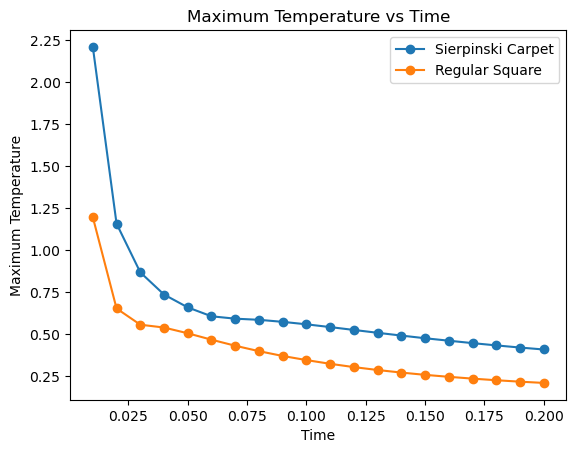

In [11]:
times = np.linspace(0.01, 0.2, 20)
carpet_max = []
square_max = []

for T in times:
    u_carpet = heat_diffusion(mask3, T)
    u_square = heat_diffusion(square_mask, T)

    carpet_max.append(np.max(u_carpet))
    square_max.append(np.max(u_square))


plt.figure()

plt.plot(times, carpet_max, marker="o", label="Sierpinski Carpet")
plt.plot(times, square_max, marker="o", label="Regular Square")

plt.xlabel("Time")
plt.ylabel("Maximum Temperature")
plt.title("Maximum Temperature vs Time")
plt.legend()

plt.show()

# Maximum Temperature
The results show that the three-iteration Sierpinski carpet maintains a higher maximum temperature throughout the simulated time interval. This is likely caused by the removed regions restricting the pathways through which heat can diffuse compared with the regular square.

As time increases, the difference between the maximum temperatures decreases. Over the later portion of the simulated interval, this difference appears to change more slowly.

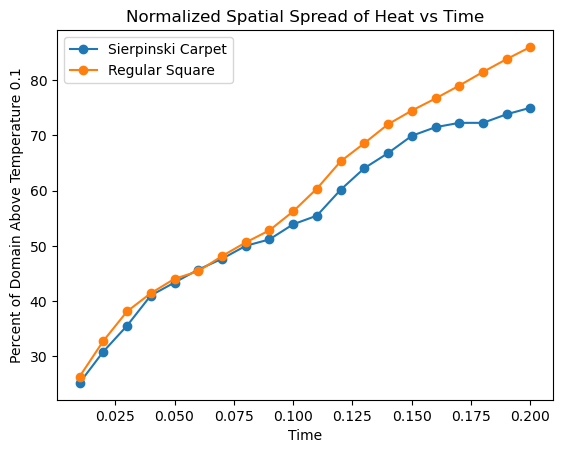

In [13]:
times = np.linspace(0.01, 0.2, 20)

carpet_spread = []
square_spread = []

threshold = 0.1

carpet_cells = np.sum(mask3 == 1)
square_cells = np.sum(square_mask == 1)

for T in times:

    u_carpet = heat_diffusion(mask3, T)
    u_square = heat_diffusion(square_mask, T)

    carpet_spread.append(
        100 * np.sum((u_carpet > threshold) & (mask3 == 1)) / carpet_cells
    )

    square_spread.append(
        100 * np.sum(u_square > threshold) / square_cells
    )


plt.figure()

plt.plot(times, carpet_spread, marker="o", label="Sierpinski Carpet")
plt.plot(times, square_spread, marker="o", label="Regular Square")

plt.xlabel("Time")
plt.ylabel("Percent of Domain Above Temperature 0.1")
plt.title("Normalized Spatial Spread of Heat vs Time")
plt.legend()

plt.show()

# Spatial Spread of Heat
The results show how the spatial spread of heat changes over time. At the beginning of the simulation, the regular square has a slightly larger normalized spatial spread. The two values later become approximately equal before the spatial spread of the regular square begins to increase relative to that of the Sierpinski carpet.

This behavior is likely caused by the removed regions of the Sierpinski carpet restricting heat diffusion. The regular square provides more continuous pathways through which heat can spread, allowing heat to reach a larger proportion of the domain.

# Conclusion and Future Work
The results demonstrate how the geometry of a Sierpinski carpet affects heat diffusion. By visualizing the temperature distributions and comparing the maximum temperature and spatial spread over time, we observe that the fractal structure restricts heat diffusion relative to a regular square surface.

Future work could include increasing the number of Sierpinski carpet iterations, although the computational cost increases substantially as the grid resolution becomes larger. Another possible extension would be to study heat diffusion in three dimensions using a Menger sponge, the three-dimensional analogue of the Sierpinski carpet. Extending the model to three dimensions would require modifying the discretization of the heat equation to include diffusion in an additional spatial direction.

Finally, the same numerical approach could be applied to other fractal geometries to investigate how different geometric structures influence heat diffusion.